# Loop – Carbohydrate Data Analysis

This notebook explores carbohydrate data from two sources in the Loop Observational Study:
1. `LOOPDeviceWizard.txt` — Bolus calculator entries (early phase, 2017-2018)
2. `LOOPDeviceFood.txt` — HealthKit meal logging (later phase, 2018-2019)

We analyze data quality, coverage, and develop filtering rules for extraction.

## Setup & Load

In [74]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)

base_path = os.path.join(os.getcwd(),'../data/raw/Loop study public dataset 2023-01-31/Data Tables')
#base_path = os.path.expanduser()

# Load data
print('Loading data...')
df_wizard = pd.read_csv(os.path.join(base_path, 'LOOPDeviceWizard.txt'), delimiter='|')#usecols=['PtID', 'UTCDtTm', 'CarbInput', 'RecID']
df_wizard['DateTime'] = pd.to_datetime(df_wizard['UTCDtTm'])
df_wizard['Source'] = 'Wizard'

df_food = pd.read_csv(os.path.join(base_path, 'LOOPDeviceFood.txt'), delimiter='|')#usecols=['PtID', 'UTCDtTm', 'CarbsNet','RecID']
df_food['DateTime'] = pd.to_datetime(df_food['UTCDtTm'])
df_food['Source'] = 'Food'

# Roster for patient info
df_roster = pd.read_csv(os.path.join(base_path, 'PtRoster.txt'), delimiter='|', usecols=['PtID', 'AgeAtEnrollment'])

print(f'Wizard raw: {len(df_wizard):,} rows, {df_wizard["PtID"].nunique()} patients')
print(f'Food raw: {len(df_food):,} rows, {df_food["PtID"].nunique()} patients')
print(f'Roster: {len(df_roster):,} patients')

Loading data...
Wizard raw: 119,354 rows, 215 patients
Food raw: 1,406,204 rows, 837 patients
Roster: 919 patients


In [75]:
display(df_wizard.head())
display(df_wizard.count())
display(df_food.head())
display(df_food.count())

,PtID,RecID,ParentLOOPDeviceUploadsID,DeviceDtTm,UTCDtTm,RecommendedCarb,RecommendedCorrection,RecommendedNet,BgInput,CarbInput,...,OriginVers,OriginType,OriginDeviceFirmwrVer,OriginDeviceHardwrVer,OriginDeviceManufact,OriginDeviceModel,OriginOperatingSystVer,OriginProductType,DateTime,Source
0,1173,1,23179,2018-08-21 23:02:03,2018-08-22 06:02:03,0.00,1.65,0.90,9.93584,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-08-22 06:02:03,Wizard
1,1173,2,23179,2018-08-21 21:33:32,2018-08-22 04:33:32,0.00,1.40,1.40,9.43627,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-08-22 04:33:32,Wizard
2,1173,3,23179,2018-08-21 18:15:09,2018-08-22 01:15:09,3.30,0.00,3.30,6.16133,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-08-22 01:15:09,Wizard
3,1173,4,23179,2018-08-21 12:25:17,2018-08-21 19:25:17,3.65,1.50,4.50,8.65917,22.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-08-21 19:25:17,Wizard
4,1173,5,23179,2018-08-21 10:25:55,2018-08-21 17:25:55,0.00,2.75,1.85,10.71290,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-08-21 17:25:55,Wizard


PtID                         119354
RecID                        119354
ParentLOOPDeviceUploadsID    119354
DeviceDtTm                   119354
UTCDtTm                      119354
RecommendedCarb              116547
RecommendedCorrection        116547
RecommendedNet               116547
BgInput                       82572
CarbInput                     87535
InsulinOnBoard                72202
InsulinCarbRatio             119273
InsulinSensitivity           112780
BgTargetLow                    4914
BgTargetHigh                 102246
BgTargetTarget               107735
BgTargetRange                   252
BolusRecID                   118382
TmZnOffset                   119354
OriginName                        0
OriginVers                        0
OriginType                        0
OriginDeviceFirmwrVer             0
OriginDeviceHardwrVer             0
OriginDeviceManufact              0
OriginDeviceModel                 0
OriginOperatingSystVer            0
OriginProductType           

,PtID,RecID,ParentLOOPDeviceUploadsID,DeviceDtTm,UTCDtTm,CarbsNet,CarbUnits,TmZnOffset,OriginName,OriginVers,OriginType,OriginDeviceFirmwrVer,OriginDeviceHardwrVer,OriginDeviceManufact,OriginDeviceModel,OriginOperatingSystVer,OriginProductType,DateTime,Source
0,1082,1,22460,NaN,2018-06-03 14:33:05,5.0,grams,NaN,com.apple.HealthKit,54,service,NaN,NaN,NaN,NaN,12.1.2,"iPhone11,8",2018-06-03 14:33:05,Food
1,1082,2,22460,NaN,2018-06-03 14:00:23,30.0,grams,NaN,com.apple.HealthKit,54,service,NaN,NaN,NaN,NaN,12.1.2,"iPhone11,8",2018-06-03 14:00:23,Food
2,1082,3,22460,NaN,2018-06-03 03:50:28,25.0,grams,NaN,com.apple.HealthKit,54,service,NaN,NaN,NaN,NaN,12.1.2,"iPhone11,8",2018-06-03 03:50:28,Food
3,1082,4,22460,NaN,2018-06-03 00:10:57,48.0,grams,NaN,com.apple.HealthKit,54,service,NaN,NaN,NaN,NaN,12.1.2,"iPhone11,8",2018-06-03 00:10:57,Food
4,1082,5,22460,NaN,2018-06-02 22:40:11,30.0,grams,NaN,com.apple.HealthKit,54,service,NaN,NaN,NaN,NaN,12.1.2,"iPhone11,8",2018-06-02 22:40:11,Food


PtID                         1406204
RecID                        1406204
ParentLOOPDeviceUploadsID    1406204
DeviceDtTm                       795
UTCDtTm                      1406204
CarbsNet                     1406199
CarbUnits                    1406199
TmZnOffset                       795
OriginName                   1405409
OriginVers                   1405401
OriginType                   1405409
OriginDeviceFirmwrVer              0
OriginDeviceHardwrVer              0
OriginDeviceManufact               0
OriginDeviceModel                  0
OriginOperatingSystVer       1405409
OriginProductType            1405409
DateTime                     1406204
Source                       1406204
dtype: int64

Only df_wizard has full calculation details (insulin sensitivity, carb ratio etc.)

## Study Design & Timeline

Study Timeline (observational study, Jan 2017 - Feb 2019):
Wizard date range (de-identified): 2018-08-27 to 2018-11-18
Food date range (de-identified): 2018-11-20 to 2019-08-11

Patient coverage:
  Wizard only: 8
  Food only: 630
  Both sources: 207
  Total unique: 845


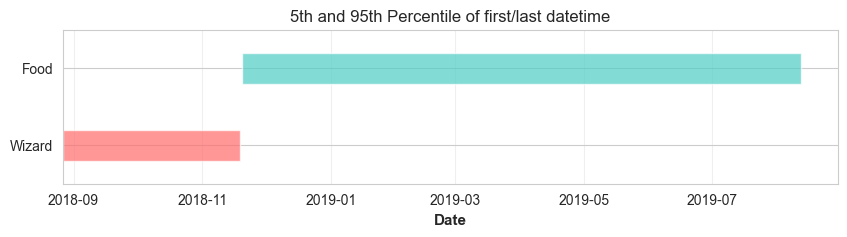

In [76]:
# Timeline analysis (for those with data in both datasets)
 
wiz_start = df_wizard.groupby('PtID').DateTime.quantile(.05).median().date()
wiz_end   = df_wizard.groupby('PtID').DateTime.quantile(.95).median().date()
fod_start = df_food.query('PtID in @df_wizard.PtID.unique()').groupby('PtID').DateTime.quantile(.05).median().date()
fod_end   = df_food.query('PtID in @df_wizard.PtID.unique()').groupby('PtID').DateTime.quantile(.95).median().date()

print("Study Timeline (observational study, Jan 2017 - Feb 2019):")
print(f"Wizard date range (de-identified): {wiz_start} to {wiz_end}")
print(f"Food date range (de-identified): {fod_start} to {fod_end}")

plt.figure(figsize=(10,2))
ax=plt.gca()
ax.barh(1, (wiz_end - wiz_start).days + 1, left=wiz_start, color='#FF6B6B', alpha=0.7, height=0.4)
ax.barh(2, (fod_end - fod_start).days + 1, left=fod_start, color='#4ECDC4', alpha=0.7, height=0.4)
ax.set_yticks([1, 2])
ax.set_yticklabels(['Wizard', 'Food'])
ax.set_xlabel('Date', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.set_ylim(0.5, 2.5)
plt.title("5th and 95th Percentile of first/last datetime")
plt.savefig('wizard_food_overlap.png',dpi=300)

# Patients in each phase
wizard_only = set(df_wizard['PtID'].unique()) - set(df_food['PtID'].unique())
food_only = set(df_food['PtID'].unique()) - set(df_wizard['PtID'].unique())
both = set(df_wizard['PtID'].unique()) & set(df_food['PtID'].unique())

print(f"\nPatient coverage:")
print(f"  Wizard only: {len(wizard_only)}")
print(f"  Food only: {len(food_only)}")
print(f"  Both sources: {len(both)}")
print(f"  Total unique: {len(wizard_only) + len(food_only) + len(both)}")



df_wizard precedes df_food. There is a transition for all patients. This is likely because the data model changes or loop supported apple health integration November, 2018. However, for df_food, calculation details are missing.

## Duplicates

In [77]:
wiz_dups = df_wizard.duplicated(subset=['PtID', 'DateTime'])
food_dups = df_food.duplicated(subset=['PtID', 'DateTime'])
print(f"  Wizard: {wiz_dups.sum():,} ({100*wiz_dups.sum()/len(df_wizard):.2f}%)")
print(f"  Food: {food_dups.sum():,} ({100*food_dups.sum()/len(df_food):.2f}%)")


  Wizard: 650 (0.54%)
  Food: 16,245 (1.16%)


In [73]:
from babelbetes import pandas_helper
# Check for duplicates
wiz_dup_all = df_wizard.duplicated(subset=['PtID', 'DateTime','CarbInput'])
food_dup_all = df_food.duplicated(subset=['PtID', 'DateTime','CarbsNet'])

print(f"\Complete duplicates (same patient + time):")
print(f"  Wizard: {wiz_dup_all.sum():,} ({100*wiz_dup_all.sum()/len(df_wizard):.2f}%)")
print(f"  Food: {food_dup_all.sum():,} ({100*food_dup_all.sum()/len(df_food):.2f}%)")

i_dup_sample = np.random.choice(df_wizard.index[wiz_dup_all])
surr = pandas_helper.extract_surrounding_rows(df_wizard,i_dup_sample,2,['PtID','DateTime'])
display(surr.dropna(how='all',axis=1))

i_dup_sample = np.random.choice(food_dup_all.index[food_dup_all])
surr = pandas_helper.extract_surrounding_rows(df_food,i_dup_sample,2,['PtID','DateTime'])
display(surr.dropna(how='all',axis=1))

#drop these
df_wizard = df_wizard.drop_duplicates(subset=['PtID', 'DateTime','CarbInput'])
df_food = df_food.drop_duplicates(subset=['PtID', 'DateTime','CarbsNet'])

\Complete duplicates (same patient + time):
  Wizard: 0 (0.00%)
  Food: 0 (0.00%)


ValueError: 'a' cannot be empty unless no samples are taken

In [ ]:
from babelbetes import pandas_helper
# Check for duplicates

wiz_dup_all = df_wizard.duplicated(subset=['PtID', 'DateTime'])
food_dup_all = df_food.duplicated(subset=['PtID', 'DateTime'])
print(f"\nTemporal duplicates (same patient + time):")
print(f"  Wizard: {wiz_dup_all.sum():,} ({100*wiz_dup_all.sum()/len(df_wizard):.2f}%)")
print(f"  Food: {food_dup_all.sum():,} ({100*food_dup_all.sum()/len(df_food):.2f}%)")

i_dup_sample = np.random.choice(df_wizard.index[wiz_dup_all])
surr = pandas_helper.extract_surrounding_rows(df_wizard,i_dup_sample,1,['PtID','DateTime'])
display(surr.dropna(how='all',axis=1))

i_dup_sample = np.random.choice(food_dup_all.index[food_dup_all])
surr = pandas_helper.extract_surrounding_rows(df_food,i_dup_sample,1,['PtID','DateTime'])
display(surr.dropna(how='all',axis=1))

#drop these
_,_,drop = pandas_helper.get_duplicated_max_indexes(df_food,['PtID', 'DateTime'],'RecID')
df_food = df_food.drop(drop)

_,_,drop = pandas_helper.get_duplicated_max_indexes(df_wizard,['PtID', 'DateTime'],'RecID')
df_wizard = df_wizard.drop(drop)

print(f"\nTemporal duplicates (same patient + time):")
n = df_wizard.duplicated(subset=['PtID', 'DateTime']).sum()
print(f"  Wizard: {n:,} ({100*n/len(df_wizard):.2f}%)")

n = df_food.duplicated(subset=['PtID', 'DateTime']).sum()
print(f"  Food: {n:,} ({100*n/len(df_food):.2f}%)")


Temporal duplicates (same patient + time):
  Wizard: 1 (0.00%)
  Food: 2,696 (0.19%)


,PtID,RecID,ParentLOOPDeviceUploadsID,DeviceDtTm,UTCDtTm,RecommendedCarb,RecommendedCorrection,RecommendedNet,CarbInput,InsulinOnBoard,InsulinCarbRatio,InsulinSensitivity,BgTargetTarget,BgTargetRange,BolusRecID,TmZnOffset,DateTime,Source
72237,270,79655,959525,2019-07-23 12:59:00,2019-07-23 19:59:00,0.89,0.0,0.90,17.0,0.06,19.0,0.0,0.0,0.0,1105482.0,-420,2019-07-23 19:59:00,Wizard
72238,270,79656,959525,2019-07-23 12:59:00,2019-07-23 19:59:00,0.53,0.0,0.55,10.0,0.96,19.0,0.0,0.0,0.0,1105483.0,-420,2019-07-23 19:59:00,Wizard
72236,270,79654,959525,2019-07-23 16:53:00,2019-07-23 23:53:00,0.89,0.0,0.90,17.0,0.00,19.0,0.0,0.0,0.0,1105478.0,-420,2019-07-23 23:53:00,Wizard


,PtID,RecID,ParentLOOPDeviceUploadsID,UTCDtTm,CarbsNet,CarbUnits,OriginName,OriginVers,OriginType,OriginOperatingSystVer,OriginProductType,DateTime,Source
1330255,139,1341083,1312419,2019-08-14 15:38:00,1.0,grams,com.apple.HealthKit,1050.4.7,service,13.3.1,"iPhone11,8",2019-08-14 15:38:00,Food
1330256,139,1341084,1312419,2019-08-14 15:38:00,0.5,grams,com.apple.HealthKit,1050.4.7,service,13.3.1,"iPhone11,8",2019-08-14 15:38:00,Food
1330253,139,1341081,1312419,2019-08-14 15:58:00,1.0,grams,com.apple.HealthKit,1050.4.7,service,13.3.1,"iPhone11,8",2019-08-14 15:58:00,Food



Temporal duplicates (same patient + time):
  Wizard: 0 (0.00%)
  Food: 0 (0.00%)


## Value Distribution

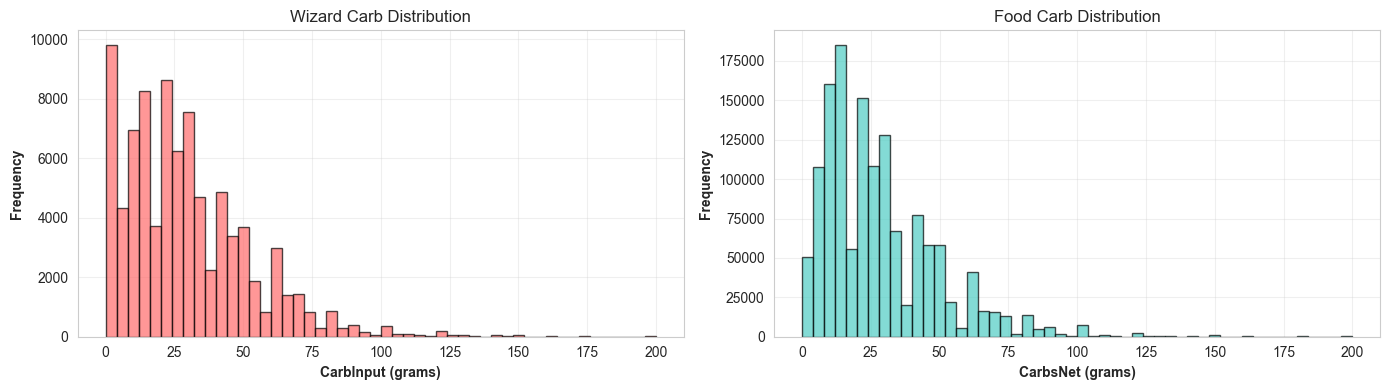

WIZARD STATISTICS
count    86885.0
mean        28.7
std         23.0
min          0.0
25%         12.0
50%         25.0
75%         40.0
max        301.0
Name: CarbInput, dtype: float64

FOOD STATISTICS
count    1389954.0
mean          27.9
std           21.4
min            0.0
25%           12.0
50%           22.0
75%           40.0
max          361.0
Name: CarbsNet, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Wizard distribution
axes[0].hist(df_wizard['CarbInput'].clip(0, 200), bins=50, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('CarbInput (grams)', fontweight='bold')
axes[0].set_ylabel('Frequency', fontweight='bold')
axes[0].set_title('Wizard Carb Distribution')
axes[0].grid(True, alpha=0.3)

# Food distribution
axes[1].hist(df_food['CarbsNet'].clip(0, 200), bins=50, color='#4ECDC4', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('CarbsNet (grams)', fontweight='bold')
axes[1].set_ylabel('Frequency', fontweight='bold')
axes[1].set_title('Food Carb Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("WIZARD STATISTICS")
print(df_wizard['CarbInput'].describe().round(1))

print("\nFOOD STATISTICS")
print(df_food['CarbsNet'].describe().round(1))

All looks normal.

## Daily Distribution Plots

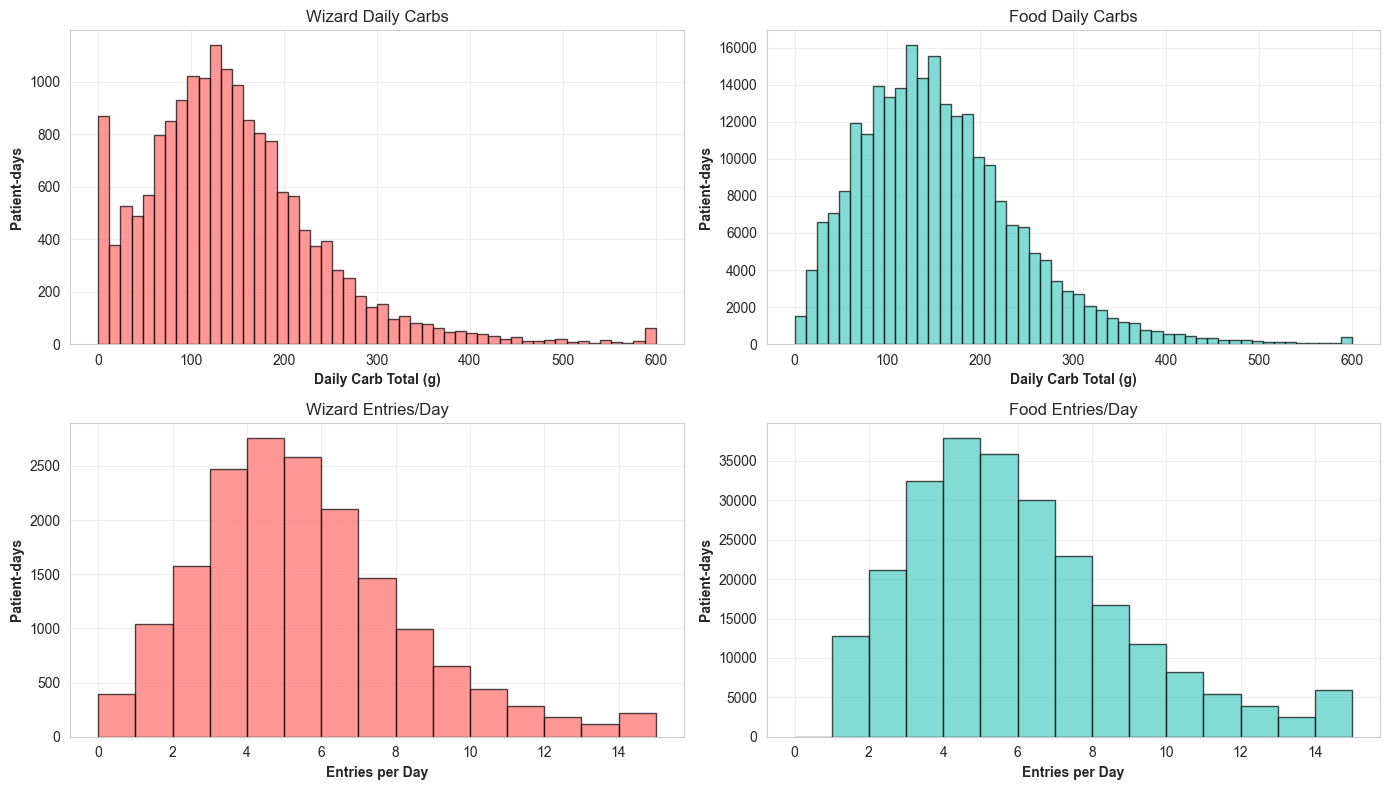

In [ ]:
# Daily totals
df_wizard['Date'] = df_wizard['DateTime'].dt.date
df_food['Date'] = df_food['DateTime'].dt.date

daily_wiz = df_wizard.groupby(['PtID', 'Date']).agg(
    daily_carbs=('CarbInput', 'sum'),
    meal_count=('CarbInput', 'count')
).reset_index()

daily_food = df_food.groupby(['PtID', 'Date']).agg(
    daily_carbs=('CarbsNet', 'sum'),
    meal_count=('CarbsNet', 'count')
).reset_index()


# Daily distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Daily carbs
axes[0, 0].hist(daily_wiz['daily_carbs'].clip(0, 600), bins=50, color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Daily Carb Total (g)', fontweight='bold')
axes[0, 0].set_ylabel('Patient-days', fontweight='bold')
axes[0, 0].set_title('Wizard Daily Carbs')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(daily_food['daily_carbs'].clip(0, 600), bins=50, color='#4ECDC4', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Daily Carb Total (g)', fontweight='bold')
axes[0, 1].set_ylabel('Patient-days', fontweight='bold')
axes[0, 1].set_title('Food Daily Carbs')
axes[0, 1].grid(True, alpha=0.3)

# Meals per day
axes[1, 0].hist(daily_wiz['meal_count'].clip(0, 15), bins=range(0, 16), color='#FF6B6B', alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Entries per Day', fontweight='bold')
axes[1, 0].set_ylabel('Patient-days', fontweight='bold')
axes[1, 0].set_title('Wizard Entries/Day')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(daily_food['meal_count'].clip(0, 15), bins=range(0, 16), color='#4ECDC4', alpha=0.7, edgecolor='black')
axes[1, 1].set_xlabel('Entries per Day', fontweight='bold')
axes[1, 1].set_ylabel('Patient-days', fontweight='bold')
axes[1, 1].set_title('Food Entries/Day')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Using df_wizard directly
wiz_coverage = df_wizard.groupby('PtID').apply(
    lambda x: 100 * (pd.to_datetime(x['UTCDtTm']).dt.date.nunique() / 
                     ((pd.to_datetime(x['UTCDtTm']).max() - pd.to_datetime(x['UTCDtTm']).min()).days + 1))
).reset_index(name='Days_Covered')

print(f"WIZARD - % of days WITHOUT data:")
print(f"  Mean: {wiz_coverage['Days_Covered'].mean():.1f}%")
print(f"  Median: {wiz_coverage['Days_Covered'].median():.1f}%")

# Using df_food directly
food_coverage = df_food.groupby('PtID').apply(
    lambda x: 100 * (pd.to_datetime(x['UTCDtTm']).dt.date.nunique() / 
                     ((pd.to_datetime(x['UTCDtTm']).max() - pd.to_datetime(x['UTCDtTm']).min()).days + 1))
).reset_index(name='Days_Covered')

print(f"\nFOOD - % of days WITHOUT data:")
print(f"  Mean: {food_coverage['Days_Covered'].mean():.1f}%")
print(f"  Median: {food_coverage['Days_Covered'].median():.1f}%")


WIZARD - % of days WITHOUT data:
  Mean: 88.0%
  Median: 100.0%



FOOD - % of days WITHOUT data:
  Mean: 88.9%
  Median: 96.1%


That's quite a lot of days with missing data.

<Axes: xlabel='Days_Covered', ylabel='Proportion'>

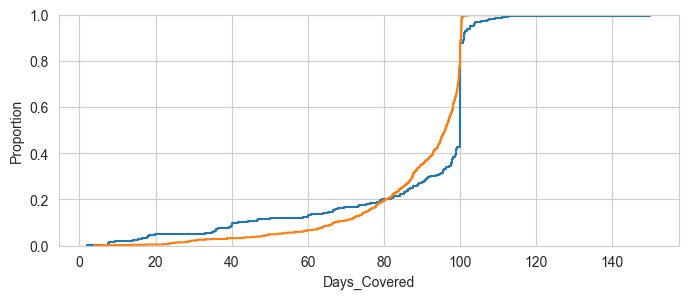

In [ ]:
f = plt.figure(figsize=(8,3))
ax=f.gca()
sns.ecdfplot(wiz_coverage,x='Days_Covered',ax=ax)
sns.ecdfplot(food_coverage,x='Days_Covered',ax=ax)

Some patients have very little data. But 80% have data for 80% of the days. 
Could be due to using loop as fully closed loop, algorithm transition, missing data,...

## Temporal Pattern by Hour

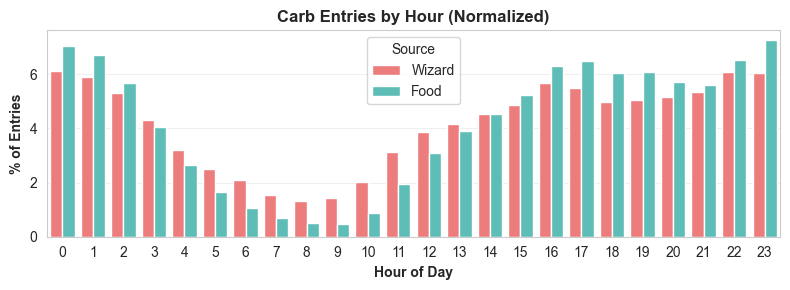

Peak hours: Wizard 0:00 (6.1%), Food 23:00 (7.2%)


In [ ]:
# Pattern by hour of day - seaborn with normalized data
fig, ax = plt.subplots(figsize=(8, 3))

wiz_by_hour = df_wizard['DateTime'].dt.hour.value_counts().sort_index()
food_by_hour = df_food['DateTime'].dt.hour.value_counts().sort_index()

# Normalize to percentage
wiz_norm = 100 * wiz_by_hour / wiz_by_hour.sum()
food_norm = 100 * food_by_hour / food_by_hour.sum()

# Create dataframes
wiz_df = pd.DataFrame({'Hour': wiz_norm.index, 'Percentage': wiz_norm.values, 'Source': 'Wizard'})
food_df = pd.DataFrame({'Hour': food_norm.index, 'Percentage': food_norm.values, 'Source': 'Food'})

combined_df = pd.concat([wiz_df, food_df], ignore_index=True)

# Plot with seaborn
sns.barplot(data=combined_df, x='Hour', y='Percentage', hue='Source', palette=['#FF6B6B', '#4ECDC4'], ax=ax)
ax.set_xlabel('Hour of Day', fontweight='bold')
ax.set_ylabel('% of Entries', fontweight='bold')
ax.set_title('Carb Entries by Hour (Normalized)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Peak hours: Wizard {wiz_by_hour.idxmax()}:00 ({wiz_norm.max():.1f}%), Food {food_by_hour.idxmax()}:00 ({food_norm.max():.1f}%)")


Not identical, but very similar distributions that follow expected drop before breakfast.

Summary:
 - df_wizard is replaced with df_food November, 2018
 - both contain carb info, but df_wizard also contained ISF/CIR, which are missing in df_food
 - Both datasets contian duplciates that are resolved keeping rows with max `RecID`
 - Many patients have days with missing carbs, unclear why but overall not surprising. 



## Values Close to Zero

In [ ]:
# Check values close to zero
print('\n=== Values Close to Zero ===')
print('\nWizard (CarbInput):')
wizard_near_zero = df_wizard[df_wizard['CarbInput'] < 1].CarbInput
display(wizard_near_zero.agg(['mean','std']))
print(f'  Entries with 0 < carbs < 1: {len(wizard_near_zero)} ({100*len(wizard_near_zero)/len(df_wizard):.3f}%)')

print('\nFood (CarbsNet):')
food_near_zero = df_food[df_food['CarbsNet'] < 1].CarbsNet
display(food_near_zero.agg(['mean','std']))
print(f'  Entries with 0 < carbs < 1: {len(food_near_zero)} ({100*len(food_near_zero)/len(df_food):.3f}%)')


=== Values Close to Zero ===

Wizard (CarbInput):


mean    0.000057
std     0.005330
Name: CarbInput, dtype: float64

  Entries with 0 < carbs < 1: 8800 (7.413%)

Food (CarbsNet):


mean    0.482643
std     0.247049
Name: CarbsNet, dtype: float64

  Entries with 0 < carbs < 1: 9942 (0.715%)


In [ ]:
small_carbs = df_food[(df_food.CarbsNet>0) & (df_food.CarbsNet<1)]
small_carbs.PtID.nunique()

546

There are many patients with carbs <1g that is surprising. Let's plot a typical day 

## Plot days with tiny carbs

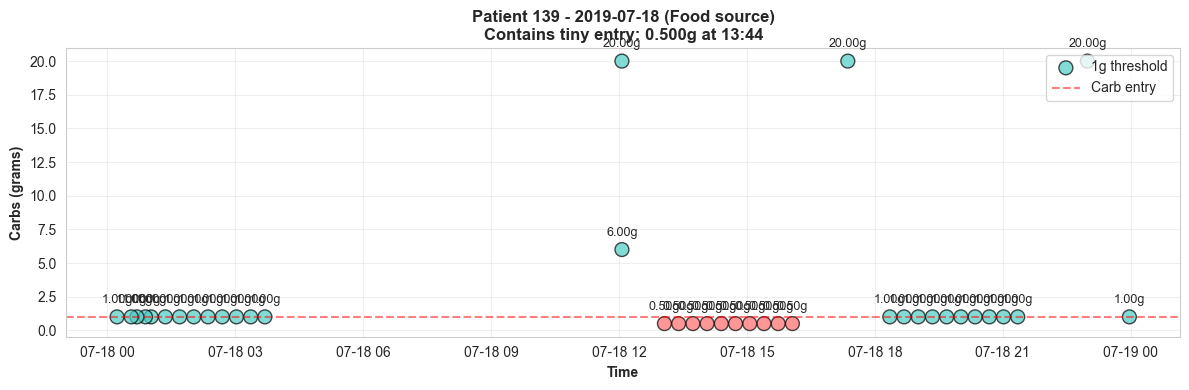


Example of a 24-hour day with a tiny carb entry:
  Patient: 139
  Date: 2019-07-18
  Source: Food
  Total entries this day: 38
  Total carbs this day: 95.0g
  Sum carbs <1 g 5.000g
  Sum carbs >=1 g 90.0g

  Tiny entry: 0.5000g at 13:44
  Likely cause: Data logging artifact, rounding error, or accidental tap in HealthKit


In [ ]:
# Plot a random 24-hour day with a tiny carb entry (<1g)
import numpy as np

# Find entries with carbs < 1g from both sources
wizard_tiny = df_wizard[df_wizard['CarbInput'] < 1].copy()
food_tiny = df_food[df_food['CarbsNet'] < 1].copy()

# Combine and pick a random one
wizard_tiny['source'] = 'Wizard'
wizard_tiny['carbs'] = wizard_tiny['CarbInput']
food_tiny['source'] = 'Food'
food_tiny['carbs'] = food_tiny['CarbsNet']

all_tiny = pd.concat([
    wizard_tiny[['PtID', 'DateTime', 'carbs', 'source']],
    food_tiny[['PtID', 'DateTime', 'carbs', 'source']]
])


# Pick random tiny entry
idx = 1238962#np.random.choice(len(all_tiny))
tiny_entry = all_tiny.iloc[idx]

pt_id = tiny_entry['PtID']
dt = tiny_entry['DateTime']
day_start = pd.Timestamp(dt.date())
day_end = day_start + pd.Timedelta(days=1)


# Get all carbs for that patient on that day
if tiny_entry['source'] == 'Wizard':
    day_carbs = df_wizard[(df_wizard['PtID'] == pt_id) & 
                            (df_wizard['DateTime'] >= day_start) & 
                            (df_wizard['DateTime'] < day_end)].copy()
    day_carbs['carbs'] = day_carbs['CarbInput']
else:
    day_carbs = df_food[(df_food['PtID'] == pt_id) & 
                        (df_food['DateTime'] >= day_start) & 
                        (df_food['DateTime'] < day_end)].copy()
    day_carbs['carbs'] = day_carbs['CarbsNet']


#display(day_carbs.dropna(axis=1,how='all'))

# Plot
fig, ax = plt.subplots(figsize=(12, 4))

colors = ['#FF6B6B' if x < 1 else '#4ECDC4' for x in day_carbs['carbs']]

ax.scatter(day_carbs['DateTime'], day_carbs['carbs'], s=100, c=colors, alpha=0.7, edgecolors='black')

for idx, row in day_carbs.iterrows():
    ax.annotate(f"{row['carbs']:.2f}g", 
                (row['DateTime'], row['carbs']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)

ax.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='1g threshold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_ylabel('Carbs (grams)', fontweight='bold')
ax.set_title(f'Patient {pt_id} - {day_start.date()} ({tiny_entry["source"]} source)\n' + 
            f'Contains tiny entry: {tiny_entry["carbs"]:.3f}g at {tiny_entry["DateTime"].strftime("%H:%M")}',
            fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(['1g threshold', 'Carb entry'], loc='upper right')

plt.tight_layout()
plt.show()

print(f"\nExample of a 24-hour day with a tiny carb entry:")
print(f"  Patient: {pt_id}")
print(f"  Date: {day_start.date()}")
print(f"  Source: {tiny_entry['source']}")
print(f"  Total entries this day: {len(day_carbs)}")
print(f"  Total carbs this day: {day_carbs['carbs'].sum():.1f}g")
print(f"  Sum carbs <1 g {day_carbs[(day_carbs.carbs<1) &(day_carbs.carbs>0)]['carbs'].sum():.3f}g")
print(f"  Sum carbs >=1 g {day_carbs[day_carbs.carbs>=1]['carbs'].sum():.1f}g")
print(f"\n  Tiny entry: {tiny_entry['carbs']:.4f}g at {tiny_entry['DateTime'].strftime('%H:%M')}")
print(f"  Likely cause: Data logging artifact, rounding error, or accidental tap in HealthKit")


From, this we can conclude that these small carb amounts are likely extended boluses.

## Timezone Correction & Local Time Patterns

In [ ]:
# Load timezone offsets
df_tz = pd.read_csv(os.path.join(base_path, 'PtRoster.txt'), delimiter='|', usecols=['PtID', 'PtTimezoneOffset'])

# Apply timezone correction to wizard
df_wizard_tz = df_wizard.merge(df_tz, on='PtID', how='left')
df_wizard_tz['LocalDateTime'] = df_wizard_tz['DateTime'] + pd.to_timedelta(df_wizard_tz['PtTimezoneOffset'], unit='hour')
df_wizard_tz['LocalHour'] = df_wizard_tz['LocalDateTime'].dt.hour

# Apply timezone correction to food
df_food_tz = df_food.merge(df_tz, on='PtID', how='left')
df_food_tz['LocalDateTime'] = df_food_tz['DateTime'] + pd.to_timedelta(df_food_tz['PtTimezoneOffset'], unit='hour')
df_food_tz['LocalHour'] = df_food_tz['LocalDateTime'].dt.hour

print('Timezone correction applied.')
print(f'  Wizard: {df_wizard_tz["PtTimezoneOffset"].notna().sum()}/{len(df_wizard_tz)} rows have timezone offset')
print(f'  Food: {df_food_tz["PtTimezoneOffset"].notna().sum()}/{len(df_food_tz)} rows have timezone offset')

Timezone correction applied.
  Wizard: 118704/118704 rows have timezone offset
  Food: 1389959/1389959 rows have timezone offset


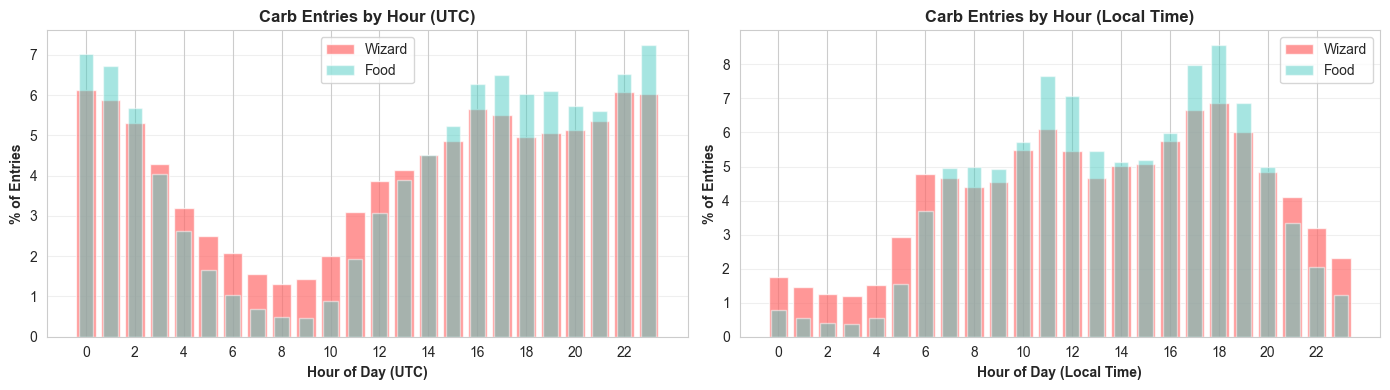


Meal time peaks (local time):
  Wizard: 18:00 (6.9%)
  Food: 18:00 (8.6%)


In [ ]:
# Plot local time patterns by hour
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# UTC time patterns
wiz_utc_by_hour = df_wizard['DateTime'].dt.hour.value_counts().sort_index()
food_utc_by_hour = df_food['DateTime'].dt.hour.value_counts().sort_index()

wiz_utc_norm = 100 * wiz_utc_by_hour / wiz_utc_by_hour.sum()
food_utc_norm = 100 * food_utc_by_hour / food_utc_by_hour.sum()

axes[0].bar(wiz_utc_norm.index, wiz_utc_norm.values, color='#FF6B6B', alpha=0.7, label='Wizard', width=0.8)
axes[0].bar(food_utc_norm.index, food_utc_norm.values, color='#4ECDC4', alpha=0.5, label='Food', width=0.6)
axes[0].set_xlabel('Hour of Day (UTC)', fontweight='bold')
axes[0].set_ylabel('% of Entries', fontweight='bold')
axes[0].set_title('Carb Entries by Hour (UTC)', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticks(range(0, 24, 2))

# Local time patterns
wiz_local_by_hour = df_wizard_tz['LocalHour'].value_counts().sort_index()
food_local_by_hour = df_food_tz['LocalHour'].value_counts().sort_index()

wiz_local_norm = 100 * wiz_local_by_hour / wiz_local_by_hour.sum()
food_local_norm = 100 * food_local_by_hour / food_local_by_hour.sum()

axes[1].bar(wiz_local_norm.index, wiz_local_norm.values, color='#FF6B6B', alpha=0.7, label='Wizard', width=0.8)
axes[1].bar(food_local_norm.index, food_local_norm.values, color='#4ECDC4', alpha=0.5, label='Food', width=0.6)
axes[1].set_xlabel('Hour of Day (Local Time)', fontweight='bold')
axes[1].set_ylabel('% of Entries', fontweight='bold')
axes[1].set_title('Carb Entries by Hour (Local Time)', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('/tmp/loop_carb_hourly_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMeal time peaks (local time):')
print(f'  Wizard: {wiz_local_by_hour.idxmax()}:00 ({wiz_local_norm.max():.1f}%)')
print(f'  Food: {food_local_by_hour.idxmax()}:00 ({food_local_norm.max():.1f}%)')